## Numerical Accuracy Benchmark for Triangular Matrix Inverse
 This notebook provides a reusable framework to compare the numerical accuracy of multiple algorithms as a function of input matrix size.

### Typical use cases:
 - Comparing different matrix inversion / multiplication algorithms
 - Studying stability vs size
 - Measuring forward/backward and absolute error

In [10]:
import numpy as np
import time
from typing import Callable, Dict

np.random.seed(0)


def generate_matrix(n: int, kind: str = "random", dtype=np.float64, scale: float=0.2) -> np.ndarray:
    """
    Generate test matrices of various types.

    Parameters
    ----------
    n : int
        Matrix dimension (n x n)
    kind : str
        Type of matrix: 'random', 'spd', 'hilbert', 'ill_conditioned'
    dtype : numpy dtype
    scale: float
        If the matrix type is random, it will be scaled by this factor.

    Returns
    -------
    A : ndarray (n x n)
    """
    if kind == "random":
        A = np.triu(scale * np.random.rand(n, n).astype(dtype))
        np.fill_diagonal(A, 1.0)
    elif kind == "random_0_5":
        A = np.triu(0.5 * np.random.rand(n, n).astype(dtype))
        np.fill_diagonal(A, 1.0)
    elif kind == "spd":
        M = np.random.randn(n, n)
        A = M.T @ M + n * np.eye(n)
    elif kind == "hilbert":
        i = np.arange(1, n + 1)
        A = 1.0 / (i[:, None] + i[None, :] - 1.0)
    elif kind == "ill_conditioned":
        U, _ = np.linalg.qr(np.random.randn(n, n))
        V, _ = np.linalg.qr(np.random.randn(n, n))
        s = np.logspace(0, -12, n)
        A = U @ np.diag(s) @ V.T
    else:
        raise ValueError(f"Unknown matrix kind: {kind}")

    return A.astype(dtype)

### Algorithms under consideration

In [11]:
import numpy as np
from math import ceil

def reference_inverse(A: np.ndarray) -> np.ndarray:
    """High-accuracy reference using NumPy (double precision)."""
    return np.linalg.inv(A)

def algo_numpy_inv(A: np.ndarray) -> np.ndarray:
    return np.linalg.inv(A.astype(np.float32))


def tri_inv_vcs(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of an invertible upper-triangular matrix U
    using the entrywise backward-substitution formula.

    Parameters
    ----------
    A : (n, n) ndarray
        Upper-triangular matrix of size n (with nonzero diagonals).

    Returns
    -------
    A_inv : Square matrix of size n.
        The inverse of A, also upper-triangular.
    """
    n = A.shape[0]
    A_inv = np.zeros_like(A, dtype=A.dtype)

    # Invert diagonal entries
    for i in range(n):
        A_inv[i, i] = 1.0 / A[i, i]

    # Compute upper-triangular off-diagonal entries
    for j in range(n):  # column
        # Compute each column backwards (from j - 1 down to 0)
        for i in range(j-1, -1, -1):
            s = 0.0
            for k in range(i+1, j+1):
                s -= (A[i, k] * A_inv[k, j]) / A[i, i]
            A_inv[i, j] = s

    return A_inv


def tri_inv_mcs(A: np.ndarray) -> np.ndarray:
  "Returns A^{-1} using backward substitution."
  n = A.shape[0]
  I_n = np.eye(n, dtype=A.dtype)

  A = 2 * I_n - A
  A_inv = I_n.copy()
  for k in reversed(range(n)):
    M = I_n.copy()
    M[:, k] = A[:, k]
    A_inv = M @ A_inv

  return A_inv


def tri_inv_mch(A: np.ndarray, refinement_steps=0, max_block_size=0) -> np.ndarray:
    """
    Compute (I + A)^{-1} without explicit inversion
    """
    n = A.shape[0]
    if max_block_size == 0:
        max_block_size = n
    max_iters = int(ceil(np.log2(max_block_size // 2)))

    I = np.eye(n, dtype=A.dtype)
    X = 2 * I - A
    Y = (A - I).copy()
    for _ in range(max_iters):
        Y = Y @ Y
        X = X + X @ Y
    for _ in range(refinement_steps):
        R = I - A @ X
        X = X + X @ R
    return X


def tri_inv_mbh(A: np.ndarray, X = None, starting_block_size = 1) -> np.ndarray:
    def even_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(0, n, 2 * bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B

    def odd_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(bsz, n, 2 * bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B

    n = A.shape[0]
    I = np.eye(n).astype(A.dtype)
    MA = -(A - I)
    if X is None:
        X = I.copy()
    block_size = starting_block_size
    while block_size < n:
        LX = even_blocks(X, block_size)
        RX = odd_blocks(X, block_size)
        X = (LX @ MA + I) @ RX + LX
        block_size = block_size * 2
    return X

def tri_inv_mxr(A, refinement_steps = 0):
    def diag_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(0, n, bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B
    n = A.shape[0]
    block_size = 16
    DA = diag_blocks(A, block_size)
    X = tri_inv_mch(DA, refinement_steps=refinement_steps, max_block_size=block_size)
    X = tri_inv_mbh(A, X, starting_block_size=block_size)
    return X

def tri_inv_ns(A, num_iters: int = 0):
    n = A.shape[-1]
    if num_iters == 0:
      num_iters = ceil(2 * np.log2(n)) # TODO(anastasios): Can num_iters be smaller than 2log(n)? 1.5x fails!

    I = np.eye(n, dtype=np.float16)

    # scale matrix for stability
    normA = np.linalg.norm(A)
    A = A / normA

    X = A.T

    for _ in range(num_iters):
        Y = A @ X
        # 2*I : can be implemented as 2 matmuls: (1) C = I @ I, (2) C += I @ I
        X = X @ (2*I - Y)


    return X / normA

# Example placeholder for a custom algorithm
# def algo_custom(A: np.ndarray) -> np.ndarray:
#     ...

ALGORITHMS: Dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "numpy_inv": algo_numpy_inv,
    "VCS": tri_inv_vcs,
    "MCS": tri_inv_mcs,
    "MCH": tri_inv_mch,
    "MBH": tri_inv_mbh,
    "MXR": tri_inv_mxr,
    "Newton-Schulz": tri_inv_ns,
    # "Custom": algo_custom
}


### Accuracy metrics (forward/backward error)

In [12]:
import numpy as np
from numpy.linalg import norm

def abs_error(X_hat: np.ndarray, X_ref: np.ndarray) -> float:
    """||X_hat - X_ref||_F / ||X_ref||_F"""
    return np.max(np.abs(X_hat - X_ref))

def forward_error(X_hat: np.ndarray, X_ref: np.ndarray) -> float:
    """||X_hat - X_ref||_F / ||X_ref||_F"""
    return norm(X_hat - X_ref, ord='fro') / norm(X_ref, ord='fro')


def backward_error(A: np.ndarray, X_hat: np.ndarray) -> float:
    """||I - A X_hat||_F"""
    n = A.shape[0]
    I = np.eye(n, dtype=A.dtype)
    return norm(I - A @ X_hat, ord='fro')

### Benchmark runner

In [ ]:
from dataclasses import dataclass
from typing import List

@dataclass
class BenchmarkConfig:
    sizes: List[int]
    dtypes: List[np.dtype]
    matrix_kind: str = "random"
    matrix_scale: float = 0.2
    repeats: int = 3

@dataclass
class Result:
    size: int
    algo: str
    dtype: str
    forward_err: float
    backward_err: float
    abs_err: float
    time_sec: float


def run_benchmark(config: BenchmarkConfig) -> List[Result]:
    results: List[Result] = []

    for dtype in config.dtypes:
        for n in config.sizes:
            A = generate_matrix(n, kind=config.matrix_kind, dtype=dtype, scale=config.matrix_scale)
            # reference always computed in float64 for stability
            X_ref = reference_inverse(A.astype(np.float64)).astype(dtype)

            for algo_name, algo_fn in ALGORITHMS.items():
                fwd_errs = []
                bwd_errs = []
                abs_errs = []
                times = []

                for _ in range(config.repeats):
                    start = time.perf_counter()
                    X_hat = algo_fn(A)
                    elapsed = time.perf_counter() - start

                    fwd_errs.append(forward_error(X_hat, X_ref))
                    bwd_errs.append(backward_error(A, X_hat))
                    abs_errs.append(abs_error(X_hat, X_ref))
                    times.append(elapsed)

                results.append(Result(
                    size=n,
                    algo=algo_name,
                    dtype=np.dtype(dtype).name,
                    forward_err=float(np.mean(fwd_errs)),
                    backward_err=float(np.mean(bwd_errs)),
                    abs_err=float(np.mean(abs_errs)),
                    time_sec=float(np.mean(times)),
                ))

    return results

## Run Benchmark


In [14]:
config = BenchmarkConfig(
    sizes=[16, 32, 64, 128],
    dtypes=[np.float32, np.float16],
    matrix_kind="random",
    matrix_scale=0.2,
    repeats=3,
)

results = run_benchmark(config)

### Process results

In [15]:
import pandas as pd

df = pd.DataFrame([r.__dict__ for r in results])
df.head(25)


,size,algo,dtype,forward_err,backward_err,abs_err,time_sec
0,16,numpy_inv,float32,0.000000e+00,6.065808e-08,0.000000e+00,0.000091
1,16,VCS,float32,6.164340e-09,6.024558e-08,1.490116e-08,0.001064
2,16,MCS,float32,1.462471e-08,8.789164e-09,2.235174e-08,0.000180
3,16,MCH,float32,1.565673e-08,8.329514e-08,2.235174e-08,0.000043
4,16,MBH,float32,1.302317e-08,7.140920e-08,1.490116e-08,0.000120
5,16,MXR,float32,1.565673e-08,8.329514e-08,2.235174e-08,0.000049
6,16,Newton-Schulz,float32,4.574617e-05,1.472367e-04,4.202873e-05,0.000157
7,32,numpy_inv,float32,0.000000e+00,1.613544e-07,0.000000e+00,0.000165
8,32,VCS,float32,8.420786e-09,1.533358e-07,1.490116e-08,0.005711
9,32,MCS,float32,2.537926e-08,3.788898e-08,2.980232e-08,0.000116


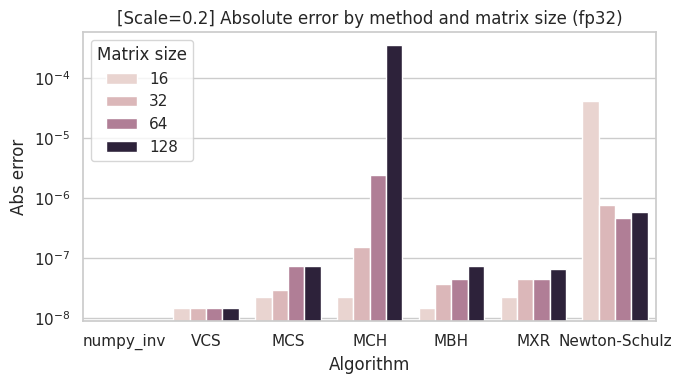

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn style
sns.set_theme(style="whitegrid")

# Ensure consistent algorithm order
algo_order = ["numpy_inv", "VCS", "MCS", "MCH", "MBH", "MXR", "Newton-Schulz"]

plt.figure(figsize=(7, 4))

sns.barplot(
    data=df[df["dtype"] == "float32"],
    x="algo",
    y="abs_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None             # disable CI bars (paper-friendly)
)

plt.yscale("log")
plt.ylabel("Abs error")
plt.xlabel("Algorithm")
plt.title("[Scale=0.2] Absolute error by method and matrix size (fp32)")
plt.legend(title="Matrix size")

plt.tight_layout()
plt.show()


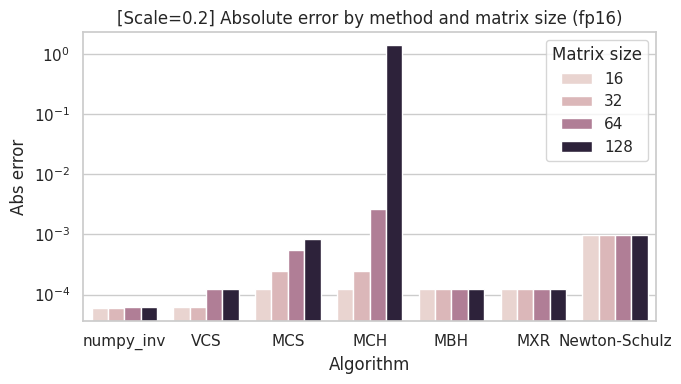

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn style
sns.set_theme(style="whitegrid")

# Ensure consistent algorithm order
algo_order = ["numpy_inv", "VCS", "MCS", "MCH", "MBH", "MXR", "Newton-Schulz"]

plt.figure(figsize=(7, 4))

sns.barplot(
    data=df[df["dtype"] == "float16"],
    x="algo",
    y="abs_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None             # disable CI bars (paper-friendly)
)

plt.yscale("log")
plt.ylabel("Abs error")
plt.xlabel("Algorithm")
plt.title("[Scale=0.2] Absolute error by method and matrix size (fp16)")
plt.legend(title="Matrix size")

plt.tight_layout()
plt.show()


## Visualization


### Save results to output

In [18]:
# Save results to CSV for paper-quality plots
output_csv = "numerical_accuracy_results.csv"
df.to_csv(output_csv, index=False)
print(f"Results saved to {output_csv}")

Results saved to numerical_accuracy_results.csv
